In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os

In [4]:
img= image.load_img('/content/drive/MyDrive/Image_binary_classification/training/happy/WhatsApp Image 2026-06-26 at 11.02.07 AM (1).jpeg')

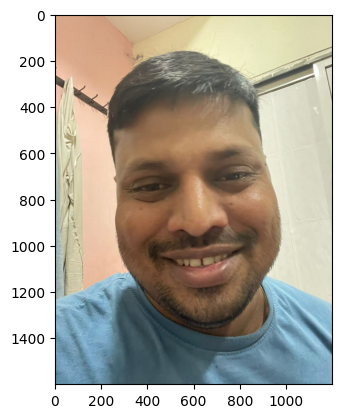

In [5]:
plt.imshow(img)

In [6]:
i1.shape

NameError: name 'i1' is not defined

In [8]:
train= ImageDataGenerator(rescale=1/200)
validation= ImageDataGenerator(rescale=1/200)

# to scale all the images i need to divide with 255
# we need to resize the image

In [9]:
train_dataset = train.flow_from_directory('/content/drive/MyDrive/Image_binary_classification/training',
                                          target_size=(200,200),
                                          batch_size=32,
                                          class_mode='binary')
validation_dataset = train.flow_from_directory('/content/drive/MyDrive/Image_binary_classification/validation',
                                          target_size=(200,200),
                                          batch_size=32,
                                          class_mode='binary')

Found 56 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [10]:
train_dataset.class_indices

{'happy': 0, 'not_happy': 1}

In [11]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [12]:

model = tf.keras.models.Sequential([tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(512,activation='relu'),
                                    tf.keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

In [17]:
model_fit= model.fit(train_dataset, epochs=20)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.8750 - loss: 0.3474
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 915ms/step - accuracy: 0.8750 - loss: 0.2875
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 618ms/step - accuracy: 0.9821 - loss: 0.1481
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 987ms/step - accuracy: 1.0000 - loss: 0.0765
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 612ms/step - accuracy: 1.0000 - loss: 0.0662
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.9286 - loss: 0.1239
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9821 - loss: 0.0542
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 632ms/step - accuracy: 1.0000 - loss: 0.0225
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 1.0000 - loss: 0.0496
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 1.0000 - loss: 0.0304
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 617ms/step - accuracy: 1.0000 - loss: 0.0122
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 600ms/step - accuracy: 1.0000 - loss: 0.0058
Epoc

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,717,764 (132.44 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,358,883 (66.22 MB)

In [19]:
dir_path = '/content/drive/MyDrive/Image_binary_classification/validation'
for i in os.listdir(dir_path):
  print(i)

happy
not_happy


In [20]:
dir_path = '/content/drive/MyDrive/Image_binary_classification/validation/happy'
for i in os.listdir(dir_path):
  img = image.load_img('/content/drive/MyDrive/Image_binary_classification/validation/happy'+i,target_size=(200,200))
  plt.imshow(img)
  plt.show()